# SQL charts: Monty answers a question, pydeno draws it

A business question gets answered through a read-only SQL tool, by two untrusted programs that
share one tool-call budget. **Python, in Monty** (pydantic's Python sandbox) calls
`describe_schema()` and `query(sql, params)` and does the wrangling — a monthly trend line, top-N
per group, a retention matrix. **JavaScript, in pydeno** (a worker process behind an OS sandbox)
takes Monty's result and turns it into an SVG chart with the vendored Vega and Vega-Lite bundles.

The SQL tool is safe in its own right, so it does not matter what SQL the model writes: the
database is a read-only in-memory copy (`PRAGMA query_only`), an authorizer allows `SELECT` and a
short list of pure functions and nothing else, results are capped, and a progress handler stops
runaway statements.

```
pip install pydeno pydantic-monty
```


## Setup

`SqlChartPipeline.render` below calls `asyncio.run(...)`, which the script can do but a notebook cell cannot (the kernel already runs an event loop). `nest_asyncio` lets a nested `asyncio.run()` work inside that loop; it changes nothing about pydeno itself.

In [1]:
from __future__ import annotations

import asyncio
import inspect
import math
import pathlib
import sqlite3
import sys
import textwrap
import threading
import time
from collections.abc import Callable
from typing import Any

import nest_asyncio

nest_asyncio.apply()

from pydeno import WEB_POLYFILLS, IsolatedRuntime, RuntimeConfig
from pydantic_monty import Monty


Resolve `vendor/libs` relative to the repository root, not `__file__` (there is no script file in a notebook).

In [2]:
def _repo_root() -> pathlib.Path:
    """Walk up from the current directory to find the pydeno checkout: this notebook is run
    with the repo root as its cwd when executed from the command line, but opening it directly
    in Jupyter normally starts in its own directory (examples/notebooks/) instead."""
    for candidate in (pathlib.Path.cwd(), *pathlib.Path.cwd().parents):
        if (candidate / "vendor" / "libs").is_dir() and (candidate / "pyproject.toml").is_file():
            return candidate
    raise RuntimeError("run this notebook from inside a pydeno checkout")


REPO_ROOT = _repo_root()
LIBS = REPO_ROOT / "vendor" / "libs"
assert LIBS.exists(), LIBS
VEGA_BUNDLES = ("vega-6.4.0.min.js", "vega-lite-6.4.3.min.js")

# Dataset sizes (orders) worth benchmarking.
SIZES = [1000, 4000, 12000, 30000]


## The data: orders, customers, products over two years, generated deterministically

In [3]:
REGIONS = ["North", "South", "East", "West"]
CATEGORIES = ["Hardware", "Software", "Services", "Training"]
FIRST = [
    "Ada",
    "Bo",
    "Cy",
    "Di",
    "Eli",
    "Fay",
    "Gus",
    "Hal",
    "Ivy",
    "Jo",
    "Kai",
    "Lee",
    "Mia",
]
LAST = [
    "Arden",
    "Birch",
    "Cole",
    "Dunn",
    "Ellis",
    "Frost",
    "Grant",
    "Hayes",
    "Ives",
    "Joy",
]
MONTHS = [f"{2023 + i // 12}-{i % 12 + 1:02d}" for i in range(24)]
SIGNUP_MONTHS = 18  # customers sign up over the first 18 months; orders run for all 24

SCHEMA_SQL = """
CREATE TABLE customers (id INTEGER PRIMARY KEY, name TEXT, region TEXT, signup_month TEXT);
CREATE TABLE products (id INTEGER PRIMARY KEY, name TEXT, category TEXT, price_cents INTEGER);
CREATE TABLE orders (
    id INTEGER PRIMARY KEY,
    customer_id INTEGER REFERENCES customers(id),
    product_id INTEGER REFERENCES products(id),
    quantity INTEGER,
    amount_cents INTEGER,
    ordered_at TEXT  -- 'YYYY-MM-DD'
);
"""


In [4]:
class _Lcg:
    """A tiny LCG: the data must not change with the Python version, so no ``random``."""

    def __init__(self, seed: int) -> None:
        self.state = seed % 2**31 or 1

    def next(self) -> float:
        self.state = (self.state * 1103515245 + 12345) % 2**31
        return self.state / 2**31

    def below(self, n: int) -> int:
        return int(self.next() * n) % n


def build_database(orders: int = 4000, seed: int = 7) -> sqlite3.Connection:
    """A writable connection holding the dataset. The model never sees this one."""
    rng = _Lcg(seed)
    conn = sqlite3.connect(":memory:")
    conn.executescript(SCHEMA_SQL)

    products = []
    for pid in range(1, 25):
        category = CATEGORIES[(pid - 1) % len(CATEGORIES)]
        price = 1500 + rng.below(40) * 2500 + (pid % 3) * 990
        products.append((pid, f"{category} {pid:02d}", category, price))
    conn.executemany("INSERT INTO products VALUES (?, ?, ?, ?)", products)

    n_customers = max(60, orders // 25)
    customers = []
    for cid in range(1, n_customers + 1):
        name = f"{FIRST[rng.below(len(FIRST))]} {LAST[rng.below(len(LAST))]} #{cid}"
        signup = rng.below(SIGNUP_MONTHS)
        # how many months a customer stays active: a few churn fast, a few never do
        lifetime = 1 + int(-6 * math.log(1 - rng.next() * 0.95))
        customers.append(
            (cid, name, REGIONS[rng.below(len(REGIONS))], signup, lifetime)
        )
    conn.executemany(
        "INSERT INTO customers VALUES (?, ?, ?, ?)",
        [(c[0], c[1], c[2], MONTHS[c[3]]) for c in customers],
    )

    rows = []
    for oid in range(1, orders + 1):
        # every customer's first order is in their signup month; the rest follow while active
        cust = (
            customers[oid - 1]
            if oid <= n_customers
            else customers[rng.below(n_customers)]
        )
        signup, lifetime = cust[3], cust[4]
        last = min(len(MONTHS) - 1, signup + lifetime)
        if oid <= n_customers:
            month = signup
        else:
            # skew towards later months, so revenue has a trend
            month = signup + int((last - signup + 1) * max(rng.next(), rng.next())) % (
                last - signup + 1
            )
        pid, _, _, price = products[rng.below(len(products))]
        qty = 1 + rng.below(5)
        day = 1 + rng.below(28)
        rows.append((oid, cust[0], pid, qty, price * qty, f"{MONTHS[month]}-{day:02d}"))
    conn.executemany("INSERT INTO orders VALUES (?, ?, ?, ?, ?, ?)", rows)
    conn.commit()
    return conn


## The host-side SQL tool: safe in its own right, whatever SQL the model writes

In [5]:
class SqlRefused(ValueError):
    """The tool refused the statement (not allowed, too big, too slow, or malformed)."""


# Pure, bounded functions. Anything else (load_extension, randomblob, zeroblob, readfile, ...) is
# refused by name, because a function call is an authorizer event of its own.
ALLOWED_FUNCTIONS = frozenset(
    """abs avg cast coalesce count date datetime group_concat ifnull iif instr length lower ltrim
    max min nullif printf round rtrim strftime substr substring sum total trim upper julianday
    typeof""".split()
)

_SELECT = sqlite3.SQLITE_SELECT
_READ = sqlite3.SQLITE_READ
_FUNCTION = sqlite3.SQLITE_FUNCTION
_RECURSIVE = getattr(sqlite3, "SQLITE_RECURSIVE", 33)


def _authorizer(action: int, arg1: Any, arg2: Any, _db: Any, _source: Any) -> int:
    if action in (_SELECT, _READ, _RECURSIVE):
        return sqlite3.SQLITE_OK
    if action == _FUNCTION and str(arg2).lower() in ALLOWED_FUNCTIONS:
        return sqlite3.SQLITE_OK
    return sqlite3.SQLITE_DENY


In [6]:
class ReadOnlyDatabase:
    """A read-only, SELECT-only, size- and time-bounded view of a database.

    Four independent layers: the copy is in-memory and ``query_only`` (no write can land), the
    authorizer refuses everything but ``SELECT`` plus an allowlist of functions (so no ``ATTACH``,
    ``PRAGMA``, DDL or ``load_extension``), the result is capped at ``row_cap`` rows, and a progress
    handler interrupts a statement that runs past ``timeout`` seconds.
    """

    MAX_SQL_CHARS = 4000

    def __init__(
        self, source: sqlite3.Connection, *, row_cap: int = 1000, timeout: float = 0.5
    ) -> None:
        self.row_cap, self.timeout = row_cap, timeout
        self.schema = self._describe(source)  # read once, by the trusted connection
        self._conn = sqlite3.connect(":memory:", check_same_thread=False)
        self._conn.deserialize(source.serialize())
        self._conn.execute("PRAGMA query_only = ON")
        self._conn.execute("PRAGMA trusted_schema = OFF")
        self._conn.setlimit(sqlite3.SQLITE_LIMIT_LENGTH, 1_000_000)
        self._conn.setlimit(sqlite3.SQLITE_LIMIT_SQL_LENGTH, self.MAX_SQL_CHARS)
        self._conn.setlimit(sqlite3.SQLITE_LIMIT_ATTACHED, 0)
        self._conn.set_authorizer(_authorizer)
        self._lock = threading.Lock()
        self._deadline = 0.0
        self._conn.set_progress_handler(self._expired, 1000)

    @staticmethod
    def _describe(conn: sqlite3.Connection) -> dict[str, Any]:
        tables: dict[str, Any] = {}
        names = [
            r[0]
            for r in conn.execute(
                "SELECT name FROM sqlite_master WHERE type='table' AND name NOT LIKE 'sqlite_%' "
                "ORDER BY name"
            )
        ]
        for name in names:
            cols = [
                {"name": c[1], "type": c[2], "primary_key": bool(c[5])}
                for c in conn.execute(
                    f"PRAGMA table_info({name})"
                )  # trusted, fixed names
            ]
            count = conn.execute(f"SELECT COUNT(*) FROM {name}").fetchone()[0]
            tables[name] = {"columns": cols, "rows": count}
        return {"tables": tables}

    def _expired(self) -> int:
        return 1 if time.monotonic() > self._deadline else 0

    def query(self, sql: str, params: Any = None) -> list[dict[str, Any]]:
        if not isinstance(sql, str):
            raise SqlRefused("sql must be a string")
        if len(sql) > self.MAX_SQL_CHARS:
            raise SqlRefused(f"statement longer than {self.MAX_SQL_CHARS} characters")
        if params is None:
            bound: Any = ()
        elif isinstance(params, (list, tuple)):
            bound = tuple(params)
        elif isinstance(params, dict):
            bound = dict(params)
        else:
            raise SqlRefused("params must be a list or a dict")
        values = bound.values() if isinstance(bound, dict) else bound
        if not all(v is None or isinstance(v, (int, float, str)) for v in values):
            raise SqlRefused("params must be numbers, strings or None")
        with self._lock:
            self._deadline = time.monotonic() + self.timeout
            try:
                cur = self._conn.execute(sql, bound)
                columns = [d[0] for d in cur.description or []]
                rows = cur.fetchmany(self.row_cap + 1)
            except sqlite3.Error as exc:
                raise SqlRefused(f"{type(exc).__name__}: {exc}") from None
            finally:
                self._deadline = float("inf")
        if not columns:
            raise SqlRefused("only SELECT statements return rows")
        if len(rows) > self.row_cap:
            raise SqlRefused(
                f"result has more than {self.row_cap} rows: aggregate or add LIMIT"
            )
        return [dict(zip(columns, row, strict=True)) for row in rows]


In [7]:
class Budget:
    """Total tool calls the model may make this turn, whichever language it calls from."""

    def __init__(self, calls: int) -> None:
        self.total, self.left = calls, calls
        self._lock = threading.Lock()

    @property
    def used(self) -> int:
        return self.total - self.left

    def tool(self, fn: Callable[..., Any]) -> Callable[..., Any]:
        def guarded(*args: Any, **kwargs: Any) -> Any:
            with self._lock:
                if self.left <= 0:
                    raise RuntimeError("tool budget exhausted")
                self.left -= 1
            return fn(*args, **kwargs)

        return guarded


class Tools:
    """The functions the model is allowed to call. Signatures and docstrings become the prompt."""

    def __init__(self, db: ReadOnlyDatabase) -> None:
        self.db = db

    def describe_schema(self) -> dict[str, Any]:
        """Tables, their columns (name, type, primary_key) and row counts."""
        return self.db.schema

    def query(
        self, sql: str, params: list[Any] | dict[str, Any] | None = None
    ) -> list[dict[str, Any]]:
        """Run ONE read-only SELECT (SQLite dialect) and return rows as dicts keyed by column.

        Bind values with ``?`` placeholders and a list, or ``:name`` and a dict. At most 1000
        rows come back, so aggregate in SQL. Dates are 'YYYY-MM-DD' text; money is integer
        cents. Anything that is not a SELECT is refused with ValueError.
        """
        return self.db.query(sql, params)


`TOOL_DESCRIPTION` is the text that would go in an LLM prompt; it is generated from the real tool signatures and docstrings, the way Monty's example generates its type stubs.

In [8]:
def tool_stubs(tools: Tools) -> str:
    """Type stubs generated from the real methods, the way Monty's example ships type_stubs.pyi."""
    out = ["from typing import Any", ""]
    for name in ("describe_schema", "query"):
        method = getattr(tools, name)
        sig = inspect.signature(method)
        doc = inspect.getdoc(method) or ""
        out.append(
            f"def {name}{str(sig).replace(chr(39), '')}:"
        )  # drop the quoting of annotations
        out.append('    """' + textwrap.indent(doc, "    ").lstrip() + '"""')
        out.append("    ...")
        out.append("")
    return "\n".join(out)


def tool_description(tools: Tools) -> str:
    """The text for an LLM prompt: what the sandbox is, what it may call, how to answer."""
    schema = tools.describe_schema()["tables"]
    tables = "\n".join(
        f"  {t}({', '.join(c['name'] + ' ' + c['type'] for c in info['columns'])})"
        for t, info in schema.items()
    )
    return (
        "Answer the business question by writing a Python program and a JavaScript program.\n"
        "\n"
        "PYTHON runs in a sandbox (Monty): no imports, no files, no network. The only functions\n"
        "it can call are these host functions; the value of the last expression is the result:\n"
        "\n" + tool_stubs(tools) + "\n"
        "Database (read-only SQLite):\n" + tables + "\n\n"
        "JAVASCRIPT runs in a second sandbox with Vega and Vega-Lite loaded (`vega`, `vegaLite`,\n"
        "`toSvg(spec)`), no fetch/require/process. It gets the Python result from `getAnalysis()`\n"
        "and may call the same two functions. It must return an SVG string.\n"
        "\n"
        "Both programs share ONE tool-call budget per question; every call counts."
    )


# The prompt text for any dataset size: it only mentions the schema, never the contents.
TOOL_DESCRIPTION = tool_description(Tools(ReadOnlyDatabase(build_database(60))))
print(TOOL_DESCRIPTION)


Answer the business question by writing a Python program and a JavaScript program.

PYTHON runs in a sandbox (Monty): no imports, no files, no network. The only functions
it can call are these host functions; the value of the last expression is the result:

from typing import Any

def describe_schema() -> dict[str, Any]:
    """Tables, their columns (name, type, primary_key) and row counts."""
    ...

def query(sql: str, params: list[Any] | dict[str, Any] | None = None) -> list[dict[str, Any]]:
    """Run ONE read-only SELECT (SQLite dialect) and return rows as dicts keyed by column.

    Bind values with ``?`` placeholders and a list, or ``:name`` and a dict. At most 1000
    rows come back, so aggregate in SQL. Dates are 'YYYY-MM-DD' text; money is integer
    cents. Anything that is not a SELECT is refused with ValueError."""
    ...

Database (read-only SQLite):
  customers(id INTEGER, name TEXT, region TEXT, signup_month TEXT)
  orders(id INTEGER, customer_id INTEGER, product_id 

## What the model wrote (hard-coded here; in real use it comes back from your LLM)

Task 1: revenue by month, with a trend line and a 3-month average.

In [9]:
PYTHON_REVENUE = """
rows = query(
    "SELECT substr(ordered_at, 1, 7) AS month, SUM(amount_cents) AS cents, COUNT(*) AS orders "
    "FROM orders GROUP BY month ORDER BY month"
)
n = len(rows)
ys = [r["cents"] / 100 for r in rows]
mean_x = (n - 1) / 2
mean_y = sum(ys) / n
sxy = 0.0
sxx = 0.0
for i in range(n):
    sxy += (i - mean_x) * (ys[i] - mean_y)
    sxx += (i - mean_x) * (i - mean_x)
slope = sxy / sxx
intercept = mean_y - slope * mean_x

months = []
for i in range(n):
    window = ys[max(0, i - 2) : i + 1]
    months.append(
        {
            "month": rows[i]["month"],
            "revenue": ys[i],
            "orders": rows[i]["orders"],
            "avg3": sum(window) / len(window),
            "trend": intercept + slope * i,
        }
    )
best = months[0]
for m in months:
    if m["revenue"] > best["revenue"]:
        best = m
{
    "summary": {
        "total": sum(ys),
        "slope_per_month": slope,
        "best_month": best["month"],
        "first": ys[0],
        "last": ys[n - 1],
    },
    "months": months,
}
"""

JAVASCRIPT_REVENUE = """
(async () => {
  const { months, summary } = getAnalysis();
  const [meta] = query('SELECT COUNT(*) AS orders, MIN(ordered_at) AS first, MAX(ordered_at) AS last FROM orders');
  const spec = {
    $schema: 'https://vega.github.io/schema/vega-lite/v5.json',
    title: { text: 'Monthly revenue', subtitle:
      `${meta.orders} orders, ${meta.first} to ${meta.last}; trend ${summary.slope_per_month >= 0 ? '+' : ''}${summary.slope_per_month.toFixed(0)} per month` },
    width: 560, height: 260,
    data: { values: months },
    encoding: { x: { field: 'month', type: 'ordinal', axis: { labelAngle: -60, title: null } } },
    layer: [
      { mark: { type: 'bar', color: '#cfd8e3' },
        encoding: { y: { field: 'revenue', type: 'quantitative', title: 'revenue' } } },
      { mark: { type: 'line', color: '#1c7ed6', strokeWidth: 2.5 },
        encoding: { y: { field: 'avg3', type: 'quantitative' } } },
      { mark: { type: 'line', color: '#e8590c', strokeDash: [6, 4], strokeWidth: 2 },
        encoding: { y: { field: 'trend', type: 'quantitative' } } },
    ],
  };
  return { svg: await toSvg(spec), datums: months.length };
})()
"""


Task 2: the top three customers per region in 2024, stacked.

In [10]:
PYTHON_TOP_CUSTOMERS = """
schema = describe_schema()
assert "orders" in schema["tables"]
rows = query(
    "SELECT c.region AS region, c.name AS customer, SUM(o.amount_cents) AS cents "
    "FROM orders o JOIN customers c ON c.id = o.customer_id "
    "WHERE o.ordered_at >= ? GROUP BY c.id ORDER BY c.region, cents DESC, c.id",
    ["2024-01-01"],
)
bars = []
seen = {}
totals = {}
for r in rows:
    region = r["region"]
    rank = seen.get(region, 0) + 1
    seen[region] = rank
    totals[region] = totals.get(region, 0) + r["cents"]
    if rank <= 3:
        bars.append(
            {"region": region, "rank": rank, "customer": r["customer"], "revenue": r["cents"] / 100}
        )
top = bars[0]
for b in bars:
    if b["revenue"] > top["revenue"]:
        top = b
{
    "summary": {
        "top_customer": top["customer"],
        "top_region": top["region"],
        "region_totals": {k: totals[k] / 100 for k in totals},
    },
    "bars": bars,
}
"""

JAVASCRIPT_TOP_CUSTOMERS = """
(async () => {
  const { bars, summary } = getAnalysis();
  const rank = (r) => ['1st', '2nd', '3rd'][r - 1];
  const data = bars.map((b) => ({ ...b, place: rank(b.rank), short: b.customer.replace(/ #\\d+$/, '') }));
  const spec = {
    $schema: 'https://vega.github.io/schema/vega-lite/v5.json',
    title: { text: 'Top three customers per region, 2024',
             subtitle: `biggest: ${summary.top_customer} (${summary.top_region})` },
    width: 360, height: 280,
    data: { values: data },
    encoding: {
      x: { field: 'region', type: 'nominal', axis: { labelAngle: 0, title: null } },
      y: { field: 'revenue', type: 'quantitative', stack: 'zero', title: 'revenue' },
      order: { field: 'rank', type: 'quantitative' },
    },
    layer: [
      { mark: { type: 'bar', stroke: 'white' },
        encoding: { color: { field: 'place', type: 'nominal', title: 'rank in region',
          scale: { range: ['#2b8a3e', '#74b816', '#b2d77a'] } } } },
      { mark: { type: 'text', fontSize: 9, color: '#222' },
        encoding: { text: { field: 'short', type: 'nominal' },
                    y: { field: 'revenue', type: 'quantitative', stack: 'zero', bandPosition: 0.5 } } },
    ],
  };
  return { svg: await toSvg(spec), datums: data.length };
})()
"""


Task 3: cohort retention. Cohort = the month a customer signed up; cell = share still ordering.

In [11]:
PYTHON_COHORTS = """
sizes = query(
    "SELECT signup_month AS cohort, COUNT(*) AS n FROM customers GROUP BY signup_month ORDER BY signup_month"
)
active = query(
    "SELECT c.signup_month AS cohort, substr(o.ordered_at, 1, 7) AS month, "
    "COUNT(DISTINCT o.customer_id) AS n "
    "FROM orders o JOIN customers c ON c.id = o.customer_id GROUP BY cohort, month"
)


def month_index(m):
    return int(m[:4]) * 12 + int(m[5:7]) - 1


size_of = {}
for s in sizes:
    size_of[s["cohort"]] = s["n"]
cells = []
by_offset = {}
for a in active:
    offset = month_index(a["month"]) - month_index(a["cohort"])
    if offset < 0 or offset > MAX_OFFSET:
        continue
    pct = round(100 * a["n"] / size_of[a["cohort"]], 1)
    cells.append({"cohort": a["cohort"], "offset": offset, "retention": pct, "active": a["n"]})
    by_offset[offset] = by_offset.get(offset, []) + [pct]
curve = []
for k in sorted(by_offset):
    curve.append({"offset": k, "mean": round(sum(by_offset[k]) / len(by_offset[k]), 1)})
cells = sorted(cells, key=lambda c: (c["cohort"], c["offset"]))
{
    "summary": {"cohorts": len(sizes), "customers": sum(size_of.values()), "curve": curve},
    "cells": cells,
    "cohorts": [{"cohort": s["cohort"], "size": s["n"]} for s in sizes],
}
"""

JAVASCRIPT_COHORTS = """
(async () => {
  const { cells, cohorts, summary } = getAnalysis();
  const [meta] = query('SELECT COUNT(DISTINCT customer_id) AS buyers FROM orders');
  const label = Object.fromEntries(cohorts.map((c) => [c.cohort, `${c.cohort} (n=${c.size})`]));
  const data = cells.map((c) => ({ ...c, cohortLabel: label[c.cohort] }));
  const spec = {
    $schema: 'https://vega.github.io/schema/vega-lite/v5.json',
    title: { text: 'Customer retention by signup cohort',
             subtitle: `${meta.buyers} of ${summary.customers} customers ever ordered` },
    width: 420, height: 340,
    data: { values: data },
    encoding: {
      x: { field: 'offset', type: 'ordinal', title: 'months since signup', axis: { labelAngle: 0 } },
      y: { field: 'cohortLabel', type: 'ordinal', title: null, sort: cohorts.map((c) => label[c.cohort]) },
    },
    layer: [
      { mark: 'rect',
        encoding: { color: { field: 'retention', type: 'quantitative', title: '% active',
          scale: { scheme: 'blues', domain: [0, 100] } } } },
      { mark: { type: 'text', fontSize: 8 },
        encoding: { text: { field: 'retention', type: 'quantitative', format: '.0f' },
                    color: { condition: { test: 'datum.retention > 55', value: 'white' }, value: '#222' } } },
    ],
  };
  return { svg: await toSvg(spec), datums: data.length };
})()
"""


The Vega/Vega-Lite glue, defined once per runtime after the libraries load, and the three tasks.

In [12]:
JS_PRELUDE = """
globalThis.toSvg = async (spec) => {
  vega.resetSVGDefIds();  // gradient and clip ids come from a global counter
  const view = new vega.View(vega.parse(vegaLite.compile(spec).spec), { renderer: 'none' });
  return await view.toSVG();
};
"""

TASKS: dict[str, dict[str, Any]] = {
    "revenue_by_month": {
        "question": "How has monthly revenue developed, and what is the trend?",
        "python": PYTHON_REVENUE,
        "javascript": JAVASCRIPT_REVENUE,
        "inputs": {},
    },
    "top_customers_by_region": {
        "question": "Who are our top customers in each region this year?",
        "python": PYTHON_TOP_CUSTOMERS,
        "javascript": JAVASCRIPT_TOP_CUSTOMERS,
        "inputs": {},
    },
    "cohort_retention": {
        "question": "How well do we retain customers, by the month they signed up?",
        "python": PYTHON_COHORTS,
        "javascript": JAVASCRIPT_COHORTS,
        "inputs": {"MAX_OFFSET": 12},
    },
}


What an attacker-model writes: the same two escapes as `monty_and_pydeno.py`, plus the SQL ones.

In [13]:
NASTY_PYTHON = "open('/etc/passwd').read()"
NASTY_JAVASCRIPT = "fetch('https://example.com')"
NASTY_SQL = [
    "DROP TABLE orders",
    "DELETE FROM orders",
    "INSERT INTO orders VALUES (0, 1, 1, 1, 1, '2024-01-01')",
    "UPDATE orders SET amount_cents = 0",
    "CREATE TABLE evil (x)",
    "ATTACH DATABASE '/tmp/evil.db' AS evil",
    "PRAGMA query_only = OFF",
    "SELECT load_extension('/tmp/evil.so')",
    "SELECT readfile('/etc/passwd')",
    "SELECT zeroblob(1000000000)",
]


## The pipeline: one database, one Monty pool, one warm pydeno runtime with Vega loaded, one budget

In [14]:
class SqlChartPipeline:
    """One database, one Monty pool, one warm pydeno runtime with Vega loaded, one budget."""

    def __init__(
        self,
        *,
        rows: int = 4000,
        budget_calls: int = 8,
        jitless: bool = True,
        row_cap: int = 1000,
        sql_timeout: float = 0.5,
    ) -> None:
        self.rows = rows
        self.budget_calls = budget_calls
        self.source = build_database(rows)
        self.db = ReadOnlyDatabase(self.source, row_cap=row_cap, timeout=sql_timeout)
        self.tools = Tools(self.db)
        self.budget = Budget(budget_calls)
        self.tool_description = tool_description(self.tools)
        self._analysis: dict[str, Any] = {}
        self.monty = Monty().__enter__()
        self.rt = IsolatedRuntime(
            RuntimeConfig(bootstrap=WEB_POLYFILLS, timeout=120.0),
            sandbox="require",
            request_timeout=300,
            jitless=jitless,
        )
        # Both sandboxes reach the tools through the budget that is current when they call.
        self.rt.bind_function("getAnalysis", lambda: self._analysis)
        self.rt.bind_function(
            "describe_schema", lambda: self.budget.tool(self.tools.describe_schema)()
        )
        self.rt.bind_function(
            "query",
            lambda sql, params=None: self.budget.tool(self.tools.query)(sql, params),
        )
        start = time.perf_counter()
        libs = "\n;\n".join((LIBS / name).read_text() for name in VEGA_BUNDLES)
        self.rt.eval(libs + "\n;0")
        self.rt.eval(JS_PRELUDE + "\n;0")
        self.load_seconds = time.perf_counter() - start

    def new_turn(self) -> Budget:
        """A fresh budget: one per question, shared by the Python and the JavaScript half."""
        self.budget = Budget(self.budget_calls)
        return self.budget

    def _external(self) -> dict[str, Callable[..., Any]]:
        return {
            "describe_schema": self.budget.tool(self.tools.describe_schema),
            "query": self.budget.tool(self.tools.query),
        }

    def prepare(self, task: str) -> dict[str, Any]:
        """Python half, in Monty. Starts a new turn (a fresh budget)."""
        self.new_turn()
        return self._prepare(task)

    def _prepare(self, task: str) -> dict[str, Any]:
        spec = TASKS[task]
        with self.monty.checkout() as session:
            return session.feed_run(
                spec["python"], inputs=spec["inputs"], external_lookup=self._external()
            )

    def render(self, task: str) -> tuple[str, dict[str, Any], dict[str, float]]:
        t0 = time.perf_counter()
        self.new_turn()
        self._analysis = self._prepare(task)
        t1 = time.perf_counter()
        out = asyncio.run(self.rt.eval_async(TASKS[task]["javascript"], timeout=120))
        t2 = time.perf_counter()
        stats = {
            "task": task,
            "datums": out["datums"],
            "tool_calls": self.budget.used,
            "summary": self._analysis["summary"],
        }
        timings = {"monty_prepare": t1 - t0, "js_build": t2 - t1, "total": t2 - t0}
        return out["svg"], stats, timings

    def __enter__(self) -> "SqlChartPipeline":
        return self

    def __exit__(self, *exc: object) -> None:
        self.close()

    def close(self) -> None:
        self.rt.close()
        self.monty.__exit__(None, None, None)
        self.db._conn.close()  # noqa: SLF001
        self.source.close()


PIPELINE = SqlChartPipeline


## Run it: build the pipeline, answer all three questions, write the SVGs

In [15]:
rows = 4000
pipe = SqlChartPipeline(rows=rows)
print(f"sandbox: {pipe.rt.sandbox}; Vega loaded in {pipe.load_seconds * 1000:.0f} ms")
print(
    f"database: {rows} orders; the model's tool description is "
    f"{len(pipe.tool_description)} characters"
)

svg_paths = {}
try:
    for task, spec in TASKS.items():
        svg, stats, t = pipe.render(task)
        out = pathlib.Path(f"{task}.svg")
        out.write_text(svg)
        svg_paths[task] = out
        print(f"\n{spec['question']}")
        print(
            f"  monty {t['monty_prepare'] * 1000:6.0f} ms | vega {t['js_build'] * 1000:6.0f} ms | "
            f"total {t['total'] * 1000:6.0f} ms | tool calls {stats['tool_calls']} of "
            f"{pipe.budget.total} | wrote {out} ({len(svg) / 1024:.0f} KiB)"
        )
finally:
    pass  # keep pipe open for the "what the sandboxes refuse" cell below


sandbox: seatbelt; Vega loaded in 36 ms
database: 4000 orders; the model's tool description is 1455 characters

How has monthly revenue developed, and what is the trend?
  monty      5 ms | vega     45 ms | total     49 ms | tool calls 2 of 8 | wrote revenue_by_month.svg (18 KiB)



Who are our top customers in each region this year?
  monty      3 ms | vega     16 ms | total     18 ms | tool calls 2 of 8 | wrote top_customers_by_region.svg (16 KiB)

How well do we retain customers, by the month they signed up?
  monty      6 ms | vega     20 ms | total     26 ms | tool calls 3 of 8 | wrote cohort_retention.svg (112 KiB)


What the sandboxes refuse, whatever SQL the model writes.

In [16]:
print("what the sandboxes refuse:")
for sql in (NASTY_SQL[0], NASTY_SQL[5], NASTY_SQL[7]):
    try:
        pipe.db.query(sql)
    except SqlRefused as exc:
        print(f"  sql {sql[:40]!r}: {str(exc)[:60]}")

pipe.close()


what the sandboxes refuse:
  sql 'DROP TABLE orders': DatabaseError: not authorized
  sql "ATTACH DATABASE '/tmp/evil.db' AS evil": DatabaseError: not authorized
  sql "SELECT load_extension('/tmp/evil.so')": OperationalError: not authorized to use function: load_exten


## The three charts

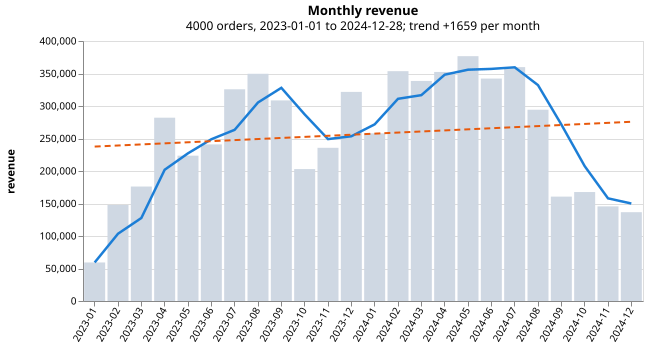

In [17]:
from IPython.display import SVG, display

display(SVG(filename=str(svg_paths["revenue_by_month"])))


Monthly revenue: bars with a 3-month moving average and a linear trend line overlaid.

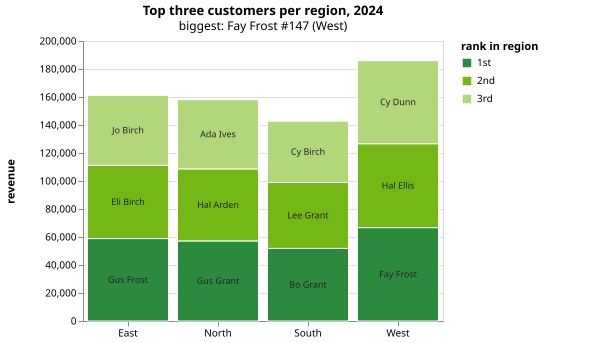

In [18]:
display(SVG(filename=str(svg_paths["top_customers_by_region"])))


Top three customers per region in 2024, stacked and ranked within each bar.

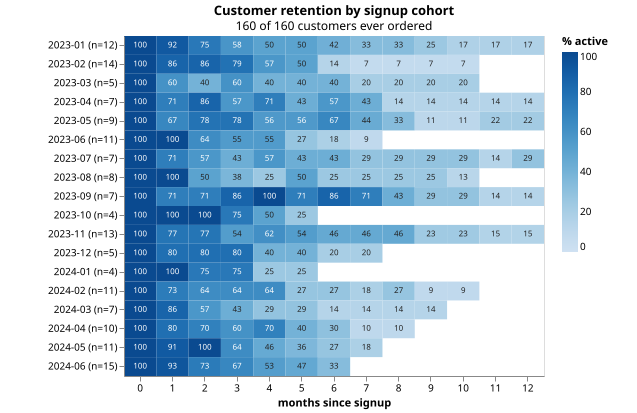

In [19]:
display(SVG(filename=str(svg_paths["cohort_retention"])))


Retention heatmap: each row is a signup cohort, each column a month since signup, cell is % still ordering.